# Segmentation RFM et Clustering afin de permettre la mise en place de stratégie marketing optimales

Une entreprise d’e-commerce veut passer d’une approche stratégique liée au « one size fits all » qui correspond à une stratégie unique appliquée à tous les clients sans distinction à une stratégie qui va consister à cibler ses actions (relance, fidélisation, cross-sell) en fonction du comportement d’achat de chaque client. Bien plus efficace que de traiter tous les clients de la même façon, cette stratégie étant aujourd’hui à l’air des données, devenus obsolète.

**Objectif :**

Segmenter les clients selon leur comportement d’achat afin de permettre à l’entreprise de prioriser les actions marketing les plus optimaux. (là où elles auront le plus d’impact)

**Questions business auxquelles le projet doit répondre :** 

- Les segments de clients les plus rentables (Client VIP, clients fidèles, clients à risque de churn, nouveaux clients, clients perdus) ?

- La part du CA provenant des clients les plus importants (par ex : du 20 % des clients, (logique pareto : environ 80 % des résultats viennent de seulement 20 % des causes. Par exemple,  20 % de vos clients rapportent 80 % de votre argent) ?

- segments à prioriser pour une campagne de réactivation ou de fidélisation ?

**Méthode pour y répondre / parvenir ? :**

- Python : nettoyage des données brutes, calcul du score RFM (Recency, Frequency, Monetary) par client, puis un clustering K-Means en complément pour valider/affiner les segments 
- SQL : recalcul du RFM via CTE et window functions, analyse Pareto, vue finale prête pour la visualisation 
- Power BI : dashboard avec vue d'ensemble du portefeuille clients, matrice de segments RFM, et détail exploitable par segment (top produits, pays, valeur) 

**Résultat attendu :**

Un livrable complet (notebook + requêtes SQL + dashboard Power BI + README) qui transforme des données transactionnelles brutes en recommandations marketing concrètes et actionnables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Exploration de la base de données : 

In [2]:
Df = pd.read_csv("C:/Users/nithi/Online_retail-rfm-segmentation/data/raw/online_retail_II.csv")

In [3]:
print(Df.shape)

(1067371, 8)


La base de donnée comprend 8 colonnes et 1 067 371 lignes (enregistrements)

In [4]:
Df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
Df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
Df[['Customer ID', 'Invoice', 'StockCode']].nunique()

Customer ID     5942
Invoice        53628
StockCode       5305
dtype: int64

On compte 5942 numéro client (Customer ID), 53 628 Factures (Invoice) et 5305 Codes (StockCode) unique. Des nombres qu'on pourra croiser avec ceux qu'on obtiendra après nettoyage pour pouvoir comparer le nombre de valeurs perdues lors du nettoyage de la base de donnée.

In [7]:
Df.duplicated().sum()

np.int64(34335)

La base de donnée contient 34335 doublons, c'est à dire des valeurs qui sont strictement identique (la même valeur dans toutes les colonnes). Les mêmes numéros clients apparaissant plusieurs fois car plusieurs commandes n'étant pas comptés.

In [8]:
Df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

On remarque qu'il y a environ 250 000 ID Client qui sont manquantes, représentant près d'un quart des ID Client totaux, ainsi que 4382 valeurs manquantes dans description.

Regardons le taux de valeurs manquante par période : 

In [9]:
pd.to_datetime(Df.loc[Df['Customer ID'].isnull(), 'InvoiceDate']).dt.to_period('M').value_counts().sort_index()

InvoiceDate
2009-12    13468
2010-01     9116
2010-02     5482
2010-03     8397
2010-04     6224
2010-05     5719
2010-06     8033
2010-07     5637
2010-08     6364
2010-09     6705
2010-10     8537
2010-11    16525
2010-12    23351
2011-01    13235
2011-02     7344
2011-03     8926
2011-04     6718
2011-05     8122
2011-06     9038
2011-07    12016
2011-08     7622
2011-09     9404
2011-10    10047
2011-11    19113
2011-12     7864
Freq: M, Name: count, dtype: int64

In [10]:
mois = pd.to_datetime(Df['InvoiceDate']).dt.to_period('M')
taux_na_mensuel = Df['Customer ID'].isnull().groupby(mois).mean() * 100

In [11]:
print(taux_na_mensuel)

InvoiceDate
2009-12    29.778014
2010-01    28.889241
2010-02    18.653872
2010-03    20.228373
2010-04    18.275244
2010-05    16.190584
2010-06    20.091039
2010-07    16.885840
2010-08    19.107668
2010-09    15.929771
2010-10    14.445497
2010-11    21.181824
2010-12    35.922405
2011-01    37.656130
2011-02    26.505937
2011-03    24.289757
2011-04    22.456211
2011-05    21.933567
2011-06    24.510495
2011-07    30.406397
2011-08    21.601859
2011-09    18.723370
2011-10    16.540450
2011-11    22.562595
2011-12    30.807804
Freq: M, Name: Customer ID, dtype: float64


Le taux de Customer ID manquants varie significativement selon la période (14% à 38%), avec une concentration plus forte en fin d'année (nov-jan), suggérant une proportion accrue d'achats occasionnels/invités pendant la période de Noël. Le nettoyage sous-représente donc légèrement cette période dans l'analyse RFM.

On vérifie qu'il n'y a pas d'incohérence dans les dates des factures (ex : 1900-01-01)

In [12]:
Df['InvoiceDate'].min(), Df['InvoiceDate'].max()

('2009-12-01 07:45:00', '2011-12-09 12:50:00')

Il n'y a pas d'incohérence à proprement parler mais nous remarquons tout de même que le mois de Décembre 2011 n'est pas complète, un élèment à prendre en compte lors du calcul du RFM, notamment pour le Recency.

In [13]:
Df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


On remarque la présence de valeurs aberrantes avec des quantités et des prix négatifs ce qui peut correspondre aux retour ou aux annulations de commande. Nous allons vérifier cette hypothèse ci-dessous, ces lignes ont un Invoice qui commence par la lettre "C".

In [14]:
# Pour les Quantités : 
Df[Df['Quantity'] < 0]['Invoice'].astype(str).str.startswith('C').mean()


np.float64(0.8493681917211329)

L'hypothèse est quasiment vérifié avec 85 % des quantités négatives provenant bien de retour ou d'annulation de commande, vérifions maintenant d'où proviennent les 15% restants.

In [15]:
Df[(Df['Quantity'] < 0) & (~Df['Invoice'].astype(str).str.startswith('C'))].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


Ce sont des ajustements de stock internes (pertes, casse, erreurs d'inventaire), pas des transactions clients. Elles n'ont ni prix ni client associé, donc aucune valeur pour l'analyse. Elles seront à enlever dans lors du nettoyage de la base.

In [16]:
mask_qty_neg_non_c = (Df['Quantity'] < 0) & (~Df['Invoice'].astype(str).str.startswith('C'))

Df[mask_qty_neg_non_c]['Customer ID'].isnull().mean() * 100

np.float64(100.0)

In [17]:
Df[Df['Price'] < 0]['Invoice'].astype(str).str.startswith('C').mean()

np.float64(0.0)

Les prix négatifs ne correspondent pas à des annulations de commandes voyons donc voir à quoi elles correspondent concrètement : 

In [18]:
(Df['Price'] < 0).sum()

np.int64(5)

In [19]:
Df[Df['Price'] < 0][['StockCode', 'Description', 'Quantity', 'Price']]

,StockCode,Description,Quantity,Price
179403,B,Adjust bad debt,1,-53594.36
276274,B,Adjust bad debt,1,-44031.79
403472,B,Adjust bad debt,1,-38925.87
825444,B,Adjust bad debt,1,-11062.06
825445,B,Adjust bad debt,1,-11062.06


Ce résultat nous prouve que les prix négatifs dans la base de donnée correspondent à des écritures comptable de régularisation confirmé par la présence de la description "Adjust bad debt" donc pas une vente.

### 1.4) Distribution des variables : 

Nous allons maintenant analyser les Outliers (valeurs extrêmes), qui peuvent venir biaiser notre analyse. Dans un premier temps, visualisons les outliers des colonnes quantités et prix à travers les graphiques suivants : des histogrammes pour analyser la distribution des quantités et des prix et une boîte à moustache (boxplot) pour analyser leurs dispersions.

<Axes: xlabel='Quantity', ylabel='Count'>

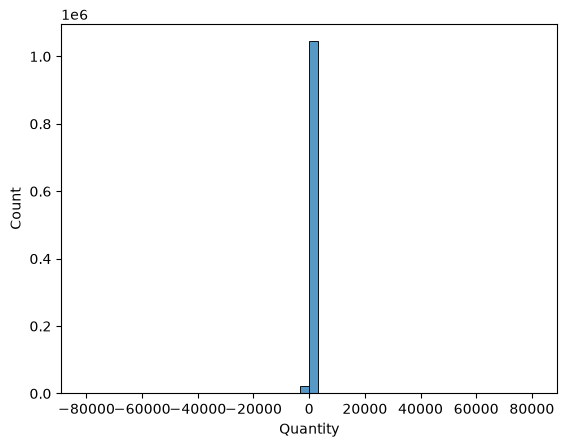

In [20]:
sns.histplot(Df['Quantity'], bins=50)

Le graphique est illisible parce que la distribution est extrêmement concentrée près de zéro avec quelques valeurs extrêmes qui étirent l'axe X jusqu'à 80 000 et - 80 000. On va donc zoomer sur la zone dense pour avoir quelque chose de plus lisible.

<Axes: xlabel='Quantity', ylabel='Count'>

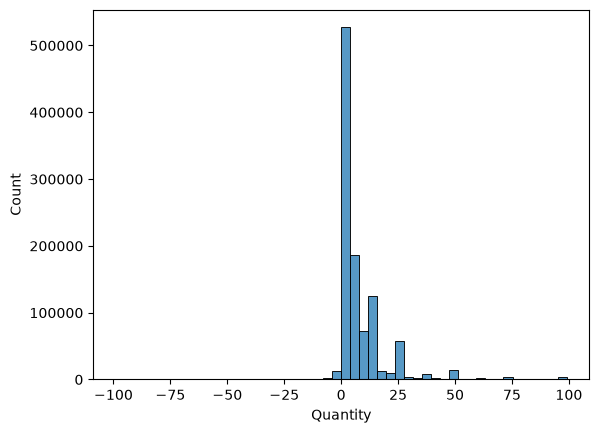

In [21]:
sns.histplot(Df[(Df['Quantity'] > -100) & (Df['Quantity'] < 100)]['Quantity'], bins=50)

La distribution des quantités nous montre que la majorité des transactions concernent de faibles volume (- de 25) avec tout de même la présence de quelques grosses quantités qui tirent la distribution vers des niveaux élevés.

<Axes: xlabel='Price', ylabel='Count'>

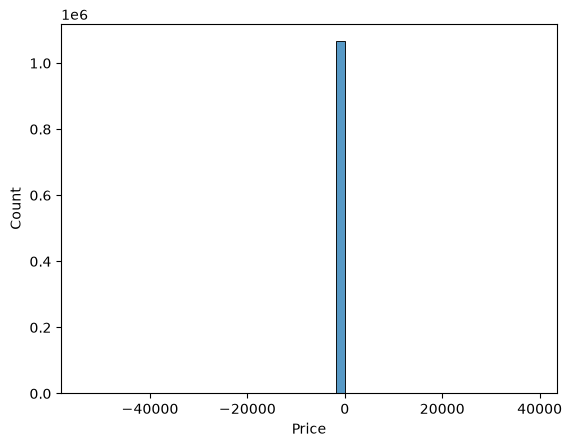

In [22]:
sns.histplot(Df['Price'], bins=50)

On va faire de même pour les Prix.

<Axes: xlabel='Price', ylabel='Count'>

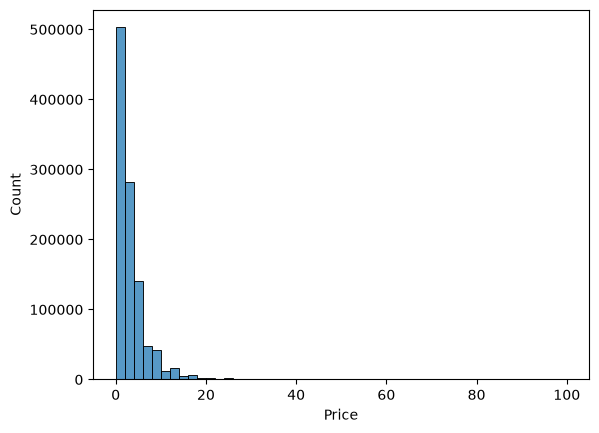

In [23]:
sns.histplot(Df[(Df['Price'] > -100) & (Df['Price'] < 100)]['Price'], bins=50)

La distribution des prix est également fortement concentrée sur des valeurs faibles, avec une asymétrie positive ce qui nous confirme la présence de produits à forte valeur mais peu fréquent dans les transactions.

Les variables Quantités et Prix présentent tous les deux une asymétrie positive qui sont caractérisées par une majorité de faibles valeurs et la présence de valeurs extrêmes qui tirent la distribution vers des niveaux élevés.

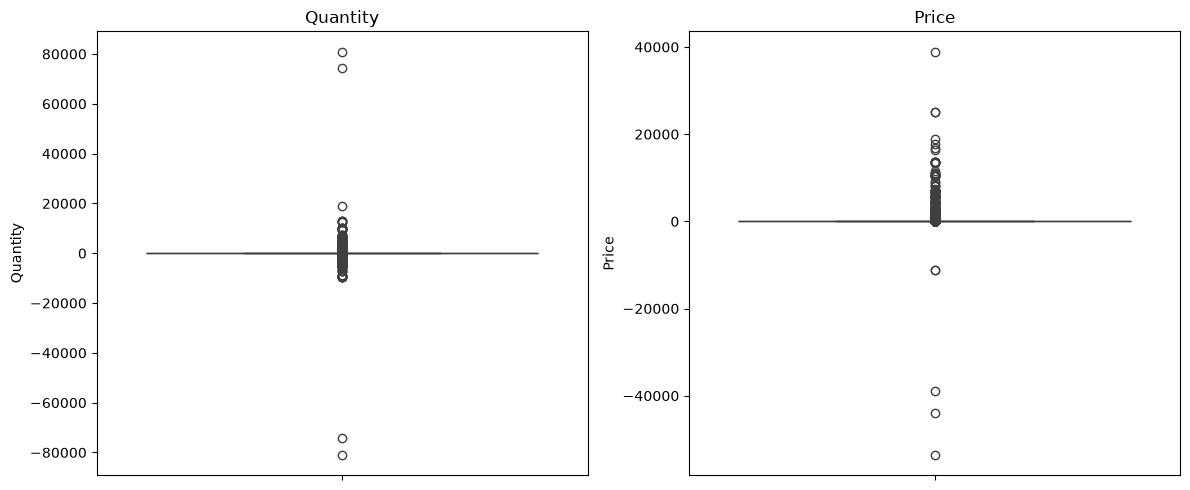

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=Df['Quantity'], ax=axes[0])
axes[0].set_title('Quantity')

sns.boxplot(y=Df['Price'], ax=axes[1])
axes[1].set_title('Price')

plt.tight_layout()
plt.show()

Le boxplot nous confirme la présence d'outliers avec la présences de plusieurs valeurs extrêmes au dessus et en dessous des boîtes, les outliers écrasent la visualisation ce qui fait qu'on arrive pas à déceler un comportement normal et donc de dégager des tendances.

Identifions clairement ce que représentent ces outliers, afin de savoir si ceux sont majoriairement les mêmes ID Clients qui reviennent avec des grosses quantités récurrentes ou s'ils s'agissent d'achats ponctuels.

In [25]:
Df[Df['Quantity'] > 1000].sort_values('Quantity', ascending=False).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.00,NaN,United Kingdom
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom


Nous remarquons qu'il y a un mélange des deux options, des achats récurrents effectués par les mêmes clients (même ID Client) ainsi que des achats ponctuel effectué par un seul client. Nous allons les garder dans notre analyse car ils répresentent un comportement d'achat réel et que nous adapterons par la suite notamment pour le clustering. Cependant nous remarquons egalement l'existence de prix = 0, regardant ce que cela signifie.

In [26]:
Df[Df['Price'] == 0].shape

(6202, 8)

In [27]:
Df[Df['Price'] == 0]['Customer ID'].isna().mean()

np.float64(0.9885520799742019)

Ces analyses confirment que ce ne sont quasiment jamais de vraies transactions clients donc probablement des erreurs de saisie, l'ID Client étant quasi-systématiquement absent (98 % des transaction avec comme prix = 0).

In [28]:
Df[Df['Customer ID'] == 12346].sort_values('InvoiceDate')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346.0,United Kingdom
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346.0,United Kingdom
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346.0,United Kingdom
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346.0,United Kingdom
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346.0,United Kingdom
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346.0,United Kingdom
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346.0,United Kingdom
71080,C495800,ADJUST,Adjustment by john on 26/01/2010 17,-1,2010-01-26 17:27:00,103.50,12346.0,United Kingdom


L'analyse du client 12346 nous révèle que ce compte contenait des produits de test et un achat massif annulé. Nous allons donc identifier toutes les valeurs de StockCode qui ne sont pas des produits. Les achats qui sont concernés par une annulation de commande seront enlevés de la base de données dans la partie suivante pour éviter de les incorporer dans notre analyse.

Nous allons d'abord identifier toutes les valeurs de StockCode qui ne sont pas numérique afin de les exclure de notre analyse dans la partie suivante lors du nettoyage de la base de données.

In [29]:
Df['StockCode'].astype(str).apply(lambda x: not x[:5].isdigit()).sum()
Df[Df['StockCode'].astype(str).apply(lambda x: not x[:5].isdigit())]['StockCode'].unique()

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',           'C3',
       'SP1002',    'AMAZONFEE',     'DCGS0055',     'DCGS0074',
     'DCGS0057',     'DCGS0073',     'DCGS0071',    'DCGS0066P',
     'DCGS0

Cela nous permet de voir qu'effectivement certains codes ne concernent pas l'achat de produits par les clients mais des codes administratifs comme ("ADJUST", "BANK CHARGES", "TEST001", "D" = Discount ...). Cependant certains codes comme ("DCGS0003", "DCGSGIRL", "GIFT", ...) méritent une analyse plus poussée afin d'eviter de les enlever alors qu'ils feraient références à des achats de produits comme des cartes cadeaux ce qui fausserait notre analyse. 

Dans le code ci-dessous nous allons donc vérifier si la colonne "Description" contient un vrai nom de produit plutôt que du texte administratif, si la colonne "Prix" a des valeurs cohérentes (ex : pas de 0) et enfin si le Le Customer ID est renseigné normalement.

In [30]:
suspect_codes = ['DCGS0003', 'DCGS0044', 'DCGSSGIRL', 'GIFT', 'gift_0001_20']

for code in suspect_codes:
    print(f"--- {code} ---")
    print(Df[Df['StockCode'] == code][['Description', 'Quantity', 'Price']].describe())
    print(Df[Df['StockCode'] == code]['Description'].unique())
    print()

--- DCGS0003 ---
        Quantity      Price
count  14.000000  14.000000
mean    0.428571   2.327857
std     2.138090   0.670490
min    -7.000000   0.000000
25%     1.000000   2.510000
50%     1.000000   2.510000
75%     1.000000   2.510000
max     1.000000   2.570000
<StringArray>
['BOXED GLASS ASHTRAY', 'ebay']
Length: 2, dtype: str

--- DCGS0044 ---
       Quantity  Price
count       1.0   1.00
mean        1.0   2.57
std         NaN    NaN
min         1.0   2.57
25%         1.0   2.57
50%         1.0   2.57
75%         1.0   2.57
max         1.0   2.57
<StringArray>
['HANDZ-OFF CAR FRESHENER']
Length: 1, dtype: str

--- DCGSSGIRL ---
         Quantity     Price
count   25.000000  25.00000
mean     7.640000   2.97320
std     19.616914   0.98636
min     -1.000000   0.00000
25%      1.000000   3.29000
50%      3.000000   3.29000
75%      5.000000   3.36000
max    100.000000   3.36000
<StringArray>
[nan, 'update', 'GIRLS PARTY BAG']
Length: 3, dtype: str

--- GIFT ---
       Quantity  P

Ces codes contiennent à la fois de vrais produits et du bruit administratif. Par exemple "DCGS00003" contient dans la description "BOXED GLASS ASHTRAY" qui est un vrai produit et "ebay" qui est quant à lui une note interne donc pas un produit. "gift_0001_20" fait bien référence à l'achat de carte cadeaux avec comme description "Dotcomgiftshop Gift Voucher...". 

La stratégie a adopté dans la partie suivante est donc la suivante : Les codes sans ambiguîté (qui ne sont pas des produits) seront exclu par "StockCode" et les codes suspects seront exclus par la colonne "Description" pour éviter d'effacer le code entier puisqu'ils contiennent également de vrais produits.

Vérifion également si les codes normaux (codes numériques) contiennent du bruit administratif dans la colonne Description. Pour se faire nous allons compter le nombre de description différentes pour un même produit afin de déceler d'eventuelle bruit administratif.

In [31]:
Df.groupby('StockCode')['Description'].nunique().sort_values(ascending=False).head(15)

StockCode
20713     9
22734     7
23084     7
22423     7
21181     7
85175     6
47566B    6
22719     6
21830     6
85123A    5
22501     5
85172     5
72807A    5
22740     5
22502     5
Name: Description, dtype: int64

Nous remarquons l'existence de StockCode avec plusieurs descriptions, vérifions pour quelques codes concernés les différentes descriptions associées.

In [32]:
Df[Df['StockCode'] == '20713']['Description'].unique()

<StringArray>
[              'JUMBO BAG OWLS',                      'missing',
                            nan, 'wrongly marked. 23343 in box',
          'wrongly coded-23343',                        'found',
                        'Found',         'wrongly marked 23343',
              'Marked as 23343',          'wrongly coded 23343']
Length: 10, dtype: str

In [33]:
Df[Df['StockCode'] == '22734']['Description'].unique()

<StringArray>
[ 'SET OF 6 RIBBONS VINTAGE CHRISTMAS', 'Carton qnty was 216 not 144 as stat',
                                   nan,                   'amazon adjustment',
                           'amendment',                              'amazon',
                        'amazon sales',                               'FOUND']
Length: 8, dtype: str

Voyons voir maintenant si ces bruits textuel sont déjà couverte par le filtre sur les Customer ID manquant :

In [34]:
Df[Df['Description'].str.lower().str.contains('wrongly|missing|found|damage|smashed|broken|faulty|amazon|adjustment', na=False)]['Customer ID'].isnull().mean()

np.float64(0.8732673267326733)

Le bruit textuel dans Description pour les codes normaux (code numérique) correspond en grande majorité à des lignes déjà couvertes par le filtre sur Customer ID manquant, pas besoin de règle de nettoyage supplémentaire sur cette colonne.

Comptons maintenant le nombre de transactions par pays afin de visualiser si des pays apparaissent beaucoup plus souvent que d'autres :

In [35]:
Df["Country"].value_counts()

Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
USA                        535
Poland                     535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


Nous allons dans cet analyse nous concentrer sur les client UK qui représente près de 92 % des commandes réalisés par les clients. Voyons voir le pourcentage de revenue des pays exclus pour quantifier l'impact de leur exclusion.

In [36]:
revenue = Df['Quantity'] * Df['Price']

In [37]:
revenue[Df['Country'] != 'United Kingdom'].sum() / revenue.sum() * 100

np.float64(15.06003492182142)

Les pays exclus représentent près de 15 % des revenus réalisées par la plateforme, creusons un peu plus afin de savoir si ces pays concentrent davantage de gros acheteurs (grossiste / B2B) ou une concentration de petits acheteurs auquelles cas leur exclusion pourraient être remise en cause.

In [38]:
Df[Df['Country'] != 'United Kingdom'].groupby('Customer ID').apply(
    lambda x: (x['Quantity'] * x['Price']).sum()
).sort_values(ascending=False).head(10)

Customer ID
14646.0    523342.07
14156.0    296564.69
14911.0    270248.53
12415.0    143269.29
17404.0     46006.82
12471.0     37948.61
12678.0     33851.13
12681.0     30551.76
13902.0     30411.26
12709.0     30312.61
dtype: float64

L'exclusion des pays hors UK retire 8% des lignes mais 15% du CA, un déséquilibre concentré sur un petit nombre de comptes (le top 4 représente plus de 70% du CA hors UK). Au moins un de ces gros comptes (client 13902, Denmark) correspond à un profil de revendeur déjà identifié dans l'analyse des quantités extrêmes (prix très bas, volumes de plusieurs milliers d'unités), ce qui appuie l'hypothèse d'un comportement B2B plutôt qu'un segment de particuliers représentatif.

In [39]:
Df[Df['Country'] == 'United Kingdom']['Customer ID'].isnull().mean() * 100

np.float64(24.459559984918428)

Le Royaume Uni compte près de 25 % de valeurs manquantes au niveau du Customer ID.

## 2) Nettoyage de la Base de données : 

#### Règles de Nettoyage : 

**Filtrer les StockCode non produit par StockCode et par Description** (pour celles qui contiennent à la fois du bruit administratif et des achats de produits). Vérification complémentaire : le bruit textuel résiduel dans Description (mots liés aux erreurs d'inventaire, dommages, ajustements multi-canal) touche à 87% des lignes déjà sans Customer ID, donc déjà couvertes par 5.1. Le reliquat (64 lignes, <0,01% du dataset) est jugé négligeable.

**Enlever les Annulations de commandes :** Suppression des lignes dont la facture commence par "C" (annulations/retours).

**Enlever les valeurs manquantes :** Suppression des lignes sans Customer ID (~24% du sous-ensemble UK, stable par rapport au taux global). Indispensable : un client sans identifiant ne peut pas être segmenté. Limite documentée : ce taux varie fortement selon la période (14% à 38%), avec une concentration en fin d'année (nov-jan), suggérant une proportion accrue d'achats occasionnels/invités pendant la période de Noël, le dataset nettoyé sous-représente donc légèrement cette période.

**Décision de périmètre :** Garder uniquement les transactions effectués au Royaume-Uni, Le Royaume-Uni représentant 92% des lignes du dataset.

**Suppression des valeurs aberrantes :** Exclusion des Quantités et Prix négatifs ainsi que des Prix = 0. Suppression des lignes avec Price ≤ 0 (prix négatifs = écritures comptables "Adjust bad debt" ; prix à 0 = quasi-exclusivement des erreurs de saisie sans client associé). Les quantités négatives résiduelles (hors annulations déjà exclues en 5.2) correspondent à des ajustements de stock internes (pertes, casse, erreurs d'inventaire), elles sont à 100% dépourvues de Customer ID et donc déjà éliminées par la règle 5.1. Les quantités extrêmes sont conservées : elles reflètent un comportement d'achat réel (gros acheteurs récurrents ou ponctuels), qui sera pris en compte dans l'interprétation des clusters plutôt qu'exclu en amont. 

**Suppression des doublons :** Suppression des lignes strictement identiques sur toutes les colonnes.

**Ajout de features (variables dérivés) :** Conversion d'InvoiceDate en type date. Création de TotalPrice (Quantity × Price), base du calcul de Monetary.




In [40]:
n_avant = Df.shape[0]
print(f"Lignes de départ : {n_avant}")

Lignes de départ : 1067371


### 2.1) Restriction du périmètre au Royaume-Uni : 

In [41]:
Df = Df[Df["Country"] == "United Kingdom"].copy()

In [42]:
print(f"Après restriction UK : {Df.shape[0]} (-{n_avant - Df.shape[0]})")
n_avant = Df.shape[0]

Après restriction UK : 981330 (-86041)


### 2.2) Gestion des valeurs manquantes : 

In [43]:
Df = Df.dropna(subset = ["Customer ID"])

In [44]:
print(f"Après suppression Customer ID manquant : {Df.shape[0]} (-{n_avant - Df.shape[0]})")
n_avant = Df.shape[0]

Après suppression Customer ID manquant : 741301 (-240029)


### 2.3) Suppression des annulations de commandes :

In [45]:
Df = Df[~Df["Invoice"].astype(str).str.startswith("C")]

In [46]:
print(f"Après suppression annulations : {Df.shape[0]} (-{n_avant - Df.shape[0]})")
n_avant = Df.shape[0]

Après suppression annulations : 725296 (-16005)


### 2.4) Suppression des StockCodes atypiques : 

In [47]:
codes_non_produits = ['POST', 'D', 'DOT', 'M', 'm', 'C2', 'C3', 'BANK CHARGES',
                       'TEST001', 'TEST002', 'ADJUST', 'ADJUST2', 'PADS',
                       'S', 'B', 'SP1002', 'AMAZONFEE', 'CRUK']

mask_codes_admin = Df['StockCode'].isin(codes_non_produits)
mask_codes_ambigus = Df['StockCode'].astype(str).str.startswith(('DCGS', 'gift_'))

Df = Df[~mask_codes_admin & ~mask_codes_ambigus]

In [48]:
print(f"Après suppression codes atypiques : {Df.shape[0]} (-{n_avant - Df.shape[0]})")
n_avant = Df.shape[0]

Après suppression codes atypiques : 724479 (-817)


### 2.5) Gestion des valeurs aberrantes : 

In [49]:
# Price <= 0 : écritures comptables (négatif) et erreurs de saisie (zéro)
# Les quantités négatives résiduelles sont déjà couvertes par 5.1 (100% sans Customer ID)

Df = Df[Df['Price'] > 0]

In [50]:
print(f"Après suppression prix <= 0 : {Df.shape[0]} (-{n_avant - Df.shape[0]})")
n_avant = Df.shape[0]

Après suppression prix <= 0 : 724440 (-39)


### 2.6) Suppression des doublons : 

In [51]:
Df = Df.drop_duplicates()

In [52]:
print(f"Après suppression doublons : {Df.shape[0]} (-{n_avant - Df.shape[0]})")

Après suppression doublons : 699608 (-24832)


### 2.7) Conversion de la date : 

In [53]:
Df['InvoiceDate'] = pd.to_datetime(Df['InvoiceDate'])

### 2.8) Variables dérivées (Features) : 

In [54]:
Df['TotalPrice'] = Df['Quantity'] * Df['Price']

In [55]:
print(Df.shape)

(699608, 9)


In [56]:
Df['Customer ID'].nunique()

5334

Le nettoyage retire 34,5% des lignes mais seulement 10,2% des clients (5 942 → 5 334), confirmant que les règles appliquées ciblent majoritairement du bruit transactionnel (annulations, doublons, codes non-produits, transactions hors UK) plutôt que d'éliminer des clients entiers de l'analyse.

### 2.9) Export de la base de donnée nettoyée : 

In [57]:
Df.to_csv('../data/processed/online_retail_clean.csv', index=False)

## 3) Analyse exploratoire : 

### 3.1) Chiffre d'affaires total et évolution mensuelle : 

Création de la variable chiffre d'affaires mensuel : 

In [58]:
ca_mensuel = Df.groupby(Df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()

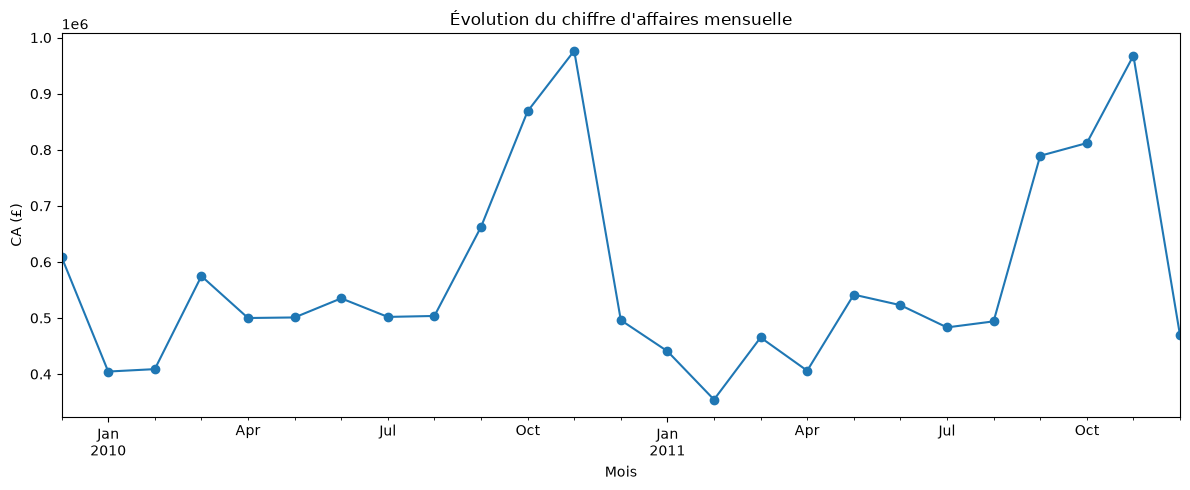

CA total : 14,288,758.75 £


In [59]:
ca_mensuel.plot(kind="line", marker="o", figsize=(12, 5))
plt.title("Évolution du chiffre d'affaires mensuelle")
plt.ylabel("CA (£)")
plt.xlabel("Mois")
plt.tight_layout()
plt.show()

print(f"CA total : {Df["TotalPrice"].sum():,.2f} £")

Le chiffre d'affaires totale de la plateforme est de 14 288 758 £. De plus, l'évolution du chiffre d'affaires mensuelles nous montre que les pics de ventes sont atteint au mois de novembre, correspondant à la période des fêtes de fin d'années. On remarque également une chute du chiffre d'affaires à partir de décembre, cependant contrairement à la chute de décembre 2010 qui elle est bien un comportement saisonnier réel, la chute de décembre 2011 et elle due à un mois incomplet dans la base de donnée et ne doit donc pas être prise en compte (s'arrêtant au 9 décembre 2011). Au final, on distingue une période basse et stable de décembre à août et une montée progressive du chiffre d'affaires de septembre à novembre, où il atteint son pic.

### 3.2) Distribution du panier moyen par commande :

Création de la variable pannier total par commande :

In [60]:
panier_par_commande = Df.groupby("Invoice")["TotalPrice"].sum()

In [61]:
print(panier_par_commande.describe())

count     33361.000000
mean        428.307267
std        1289.118364
min           0.380000
25%         154.990000
50%         299.450000
75%         449.150000
max      168469.600000
Name: TotalPrice, dtype: float64


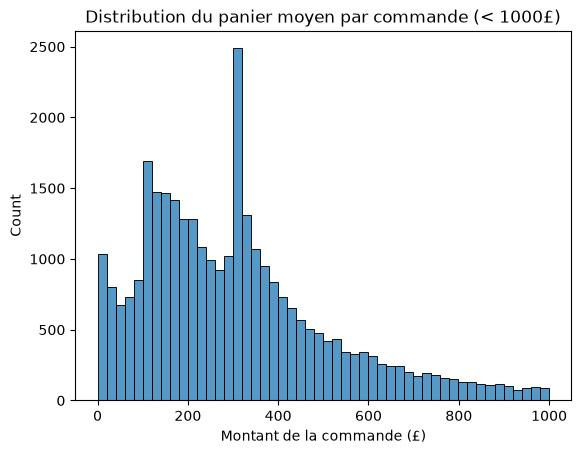

In [62]:
sns.histplot(panier_par_commande[panier_par_commande < 1000], bins=50)
plt.title("Distribution du panier moyen par commande (< 1000£)")
plt.xlabel("Montant de la commande (£)")
plt.show()

Le distribution du panier moyen par commande nous montre que près des 3/4 des commandes effectuées sont inférieurs à 500 £, avec un pic de commande autour des 250 £. La présence de quelques grosses commandes (> 500 £) tirent la distribution vers la droite représentant une asymétrie positive. Nous avons ici limité la distribution aux panier < 1000 £ pour zoomer sur la zone dense pour une question de lisibilité du graphique.

### 3.3) Nombre de commandes par client : 

Création de la variable commande par client : 

In [63]:
commande_par_client = Df.groupby("Customer ID")["Invoice"].nunique()

In [64]:
print(commande_par_client.describe())

count    5334.000000
mean        6.254406
std        11.882068
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       322.000000
Name: Invoice, dtype: float64


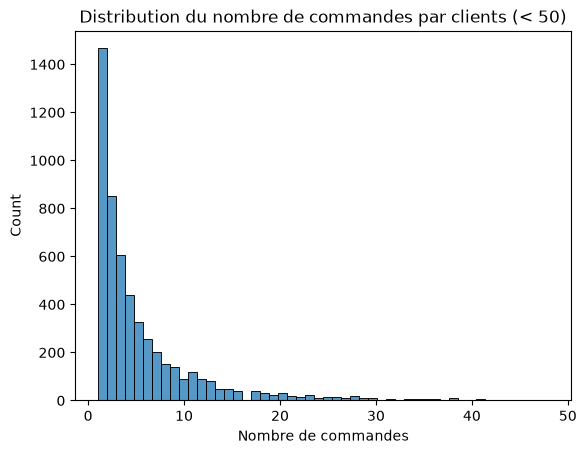

In [65]:
sns.histplot(commande_par_client[commande_par_client < 50], bins=50)
plt.title("Distribution du nombre de commandes par clients (< 50)")
plt.xlabel("Nombre de commandes")
plt.show()

La distribution du nombre de commandes par clients est egalement limitée à 50 commandes pour zoomer sur la zone dense pour la lisibilité du graphique comme effectué précèdemment. Ce graphique nous montre que plus des 3/4 du nombre de commandes par clients sont inférieurs à 7 commandes par clients. La présence encore une fois de quelques clients qui passent un nombre de commandes très élevés (> 20) tirent la distribution vers la droite (asymétrie positive).

Cette distribution confirme qu'une majorité de clients sont des acheteurs occasionnels, avec une minorité de clients très réguliers, cette hétérogénéité est justement ce que la segmentation RFM  et le clustering chercheront à capturer et à différencier.

### 3.4) Top 10 produits par quantité et par chiffre d'affaires : 

Création des variables top produit par quantité et par chiffre d'affaires : 

In [66]:
top_produit_par_quantité = Df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

In [67]:
top_produit_par_ca = Df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

In [68]:
print(top_produit_par_quantité)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     96736
WHITE HANGING HEART T-LIGHT HOLDER    84446
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        76919
ASSORTED COLOUR BIRD ORNAMENT         72577
BROCADE RING PURSE                    69714
JUMBO BAG RED RETROSPOT               67526
PACK OF 60 PINK PAISLEY CAKE CASES    44968
60 TEATIME FAIRY CAKE CASES           40144
SMALL POPCORN HOLDER                  39202
Name: Quantity, dtype: int64


In [69]:
print(top_produit_par_ca)

Description
WHITE HANGING HEART T-LIGHT HOLDER    227810.16
REGENCY CAKESTAND 3 TIER              225862.45
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               122127.13
ASSORTED COLOUR BIRD ORNAMENT         115444.33
PARTY BUNTING                          94525.03
MEDIUM CERAMIC TOP STORAGE JAR         80291.44
PAPER CHAIN KIT 50'S CHRISTMAS         73564.93
CHILLI LIGHTS                          67996.20
BLACK RECORD COVER FRAME               61324.55
Name: TotalPrice, dtype: float64


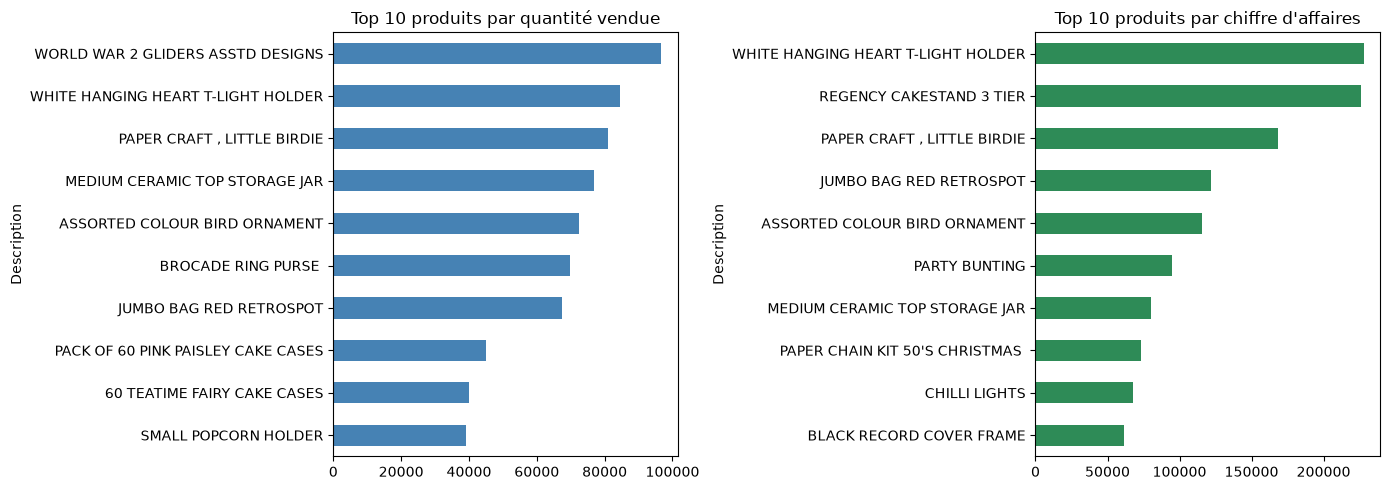

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_produit_par_quantité.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 produits par quantité vendue")
axes[0].invert_yaxis()

top_produit_par_ca.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 produits par chiffre d'affaires")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cet histogramme horizontal nous permet de voir le top 10 des produits par quantités vendue et le top 10 par chiffre d'affaires. On remarque que certains des produits présent dans le top 10 des produits par quantité vendue ne sont pas nécessairement présent dans le top 10 par chiffre d'affaires comme "WORLD WAR 2 GLIDERS ASSTD DESIGNS" ou encore "PACK OF 60 PINK PAISLEY CAKE CASES", tous deux présent dans le top 10 par quantité mais pas dans le top 10 par chiffre d'affaires, cela suggère des articles à très faible prix unitaire vendus en très grandes volumes. "WORLD WAR 2 GLIDERS ASSTD DESIGNS" est le produits le plus acheté et demandé par les clients, suivis de "WHITE HANGING HEART T-LIGHT HOLDER" et "PAPER CRAFT, LITTLE BIRDIE", tandis que "WHITE HANGING HEART T-LIGHT HOLDER" est le produit générant le plus gros chiffre d'affaires pour la plateforme, suivis par "RECENCY CAKESTAND 3 TIER" et "PAPER CRAFT, LITTLE BIRDIE".

### 3.5) Saisonnalité : 

In [71]:
Df["Month"] = Df["InvoiceDate"].dt.month

Création de la variable chiffre d'affaire par mois (toute année confondues) :

In [72]:
ca_par_mois_annee = Df.groupby("Month")["TotalPrice"].sum()

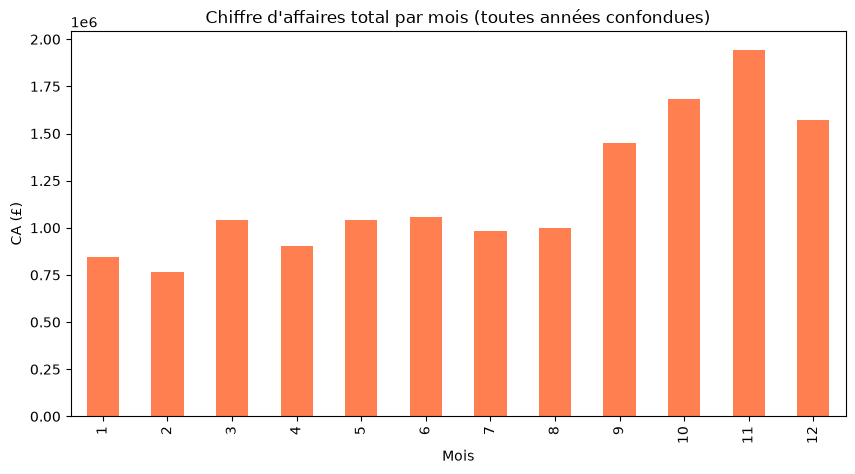

In [73]:
ca_par_mois_annee.plot(kind="bar", figsize=(10, 5), color="coral")
plt.title("Chiffre d'affaires total par mois (toutes années confondues)")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.show()

L'analyse de la saisonnalité sur le chiffre d'affaires par mois toutes années confondues confirme les hypothèses faites lors de l'analyse de l'évolution du chiffre d'affaires mensuelle, le mois de novembre est bien le mois le plus prolifique pour la plateforme, suivi des mois d'octobre, de décembre et de septembre. Ces mois correspondant à la période des fêtes de fin d'années, période connue pour enregistrer des pics de ventes. Cependant, le mois de décembre est incomplet pour l'année 2011 car la base de donnée s'arrête au 9 décembre 2011, la barre 12 représente donc ici 2 mois + 9 jours plutôt que 3 mois comme pour les autres barres, les chiffres du mois de décembre peuvent alors être sous-estimés, l'effet saisonnier de décembre est donc probablement encore plus fort que ce que montre ce graphique. Enfin, le chiffre d'affaires total pour les mois restants est relativement stable comme évoqué précédemment lors de l'analyse du chiffre d'affaires mensuelle.

## 4) Feature Engineering (Calcul RFM) :

### 4.1) Définition de la date de référence :

In [74]:
reference_date = Df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Date de référence : {reference_date}")

Date de référence : 2011-12-10 12:49:00


La convention standard en RFM est de prendre le jour suivant la dernière transaction observée comme point de référence pour calculer la Recency, plutôt que la dernière date elle-même (sinon le client le plus récent aurait une Recency de 0 jour exactement). Dans notre base de donnée les transactions s'arrêtent au 9 décembre 2011 comme identifié précèdemment, la date de référence sera alors le 10 décembre 2011.

### 4.2) Calcul de RFM par client : 

In [75]:
rfm = Df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,3,77352.96
1,12608.0,405,1,415.79
2,12745.0,487,2,723.85
3,12746.0,541,1,254.55
4,12747.0,2,26,8898.48


La recency (R) représente pour chaque client, toutes ces dates de commandes. Il prend la date la plus récente et la soustrait à la date de référence pour obtenir un nombre de jours suivant son dernier achat. Ensuite, la frequency (F) compte le nombre de factures distinctes par client et enfin, la monetary (M) représente le chiffre d'affaires généré par chaque client.

In [76]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5334.000000,5334.000000,5334.000000,5334.000000
mean,15559.706599,202.570679,6.254406,2678.807415
std,1581.170557,209.812510,11.882068,11670.338864
min,12346.000000,1.000000,1.000000,2.950000
25%,14191.250000,26.000000,1.000000,329.375000
50%,15570.500000,97.000000,3.000000,829.440000
75%,16924.750000,381.000000,7.000000,2154.747500
max,18287.000000,739.000000,322.000000,580987.040000


### 4.3) Distribution de RFM :

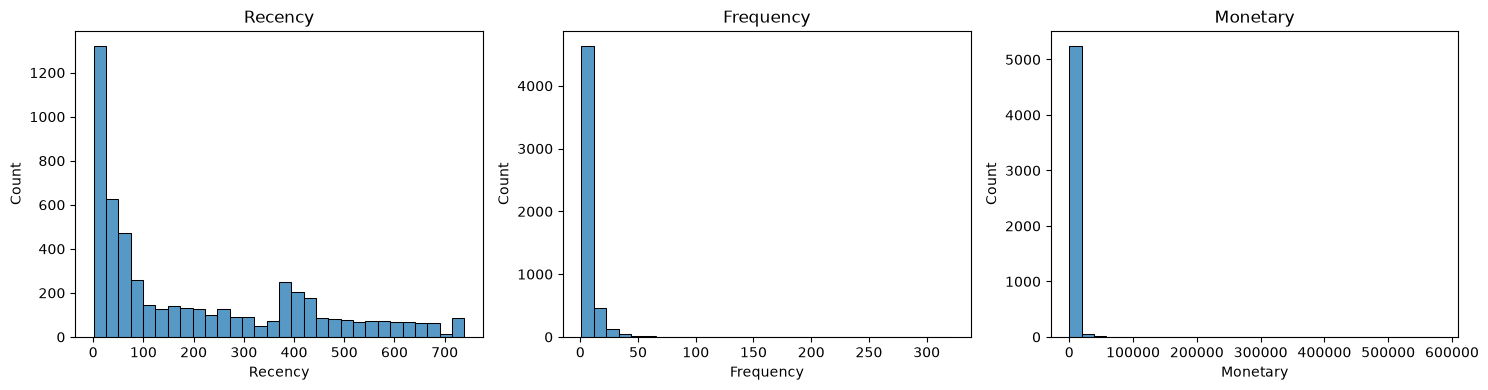

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary')

plt.tight_layout()
plt.show()

La distribution de Recency présente un second mode autour de 350-450 jours, suggérant un groupe de clients ponctuels (achat unique, souvent en période de fêtes) n'étant jamais revenus depuis. Ce groupe sera à surveiller lors de l'interprétation des clusters (section 6.4), il pourrait correspondre à un segment 'clients perdus' ou 'achat unique'.

Contrairement à Frequency et Monetary, la distribution de Recency ne présente pas d'asymétrie marquée ; une transformation log n'est donc pas justifiée pour cette variable.

Visualisons maintenant l'effet d'une transformation log sur Monetary et Frequency :

Monetary : 

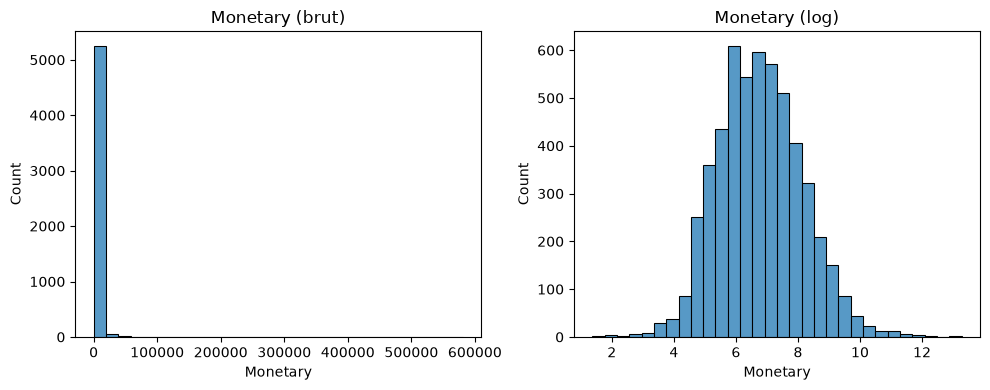

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(rfm['Monetary'], bins=30, ax=axes[0])
axes[0].set_title('Monetary (brut)')

sns.histplot(np.log1p(rfm['Monetary']), bins=30, ax=axes[1])
axes[1].set_title('Monetary (log)')

plt.tight_layout()
plt.show()

Le log transforme effectivement une distribution complètement illisible (tout écrasé dans la première barre, à cause des gros comptes B2B comme 14646 à 523k£) en une forme beaucoup plus proche d'une distribution normale/symétrique (le pic autour de 6-7 avec une décroissance de part et d'autre). Sans cette transformation, le K-means serait entièrement dominé par l'échelle de Monetary et les quelques valeurs extrêmes.

La distribution brute de Monetary est entièrement dominée par un petit nombre de comptes à très fort CA (cf. l'analyse des gros acheteurs internationaux en étape 4, clients 14646, 14156, 14911, 12415), qui apparaissent comme des valeurs extrêmes isolées sur cet histogramme. Ces clients, déjà identifiés comme ayant un profil probable de revendeurs/grossistes, sont à surveiller particulièrement lors de l'interprétation des clusters (section 6.4) : ils pourraient former un cluster à part entière plutôt que de se fondre dans un segment 'gros dépensiers' classique.

La transformation log réduit fortement cette asymétrie, mais une légère traîne résiduelle vers la droite subsiste, cohérente avec la présence de quelques gros comptes.

Frequency : 

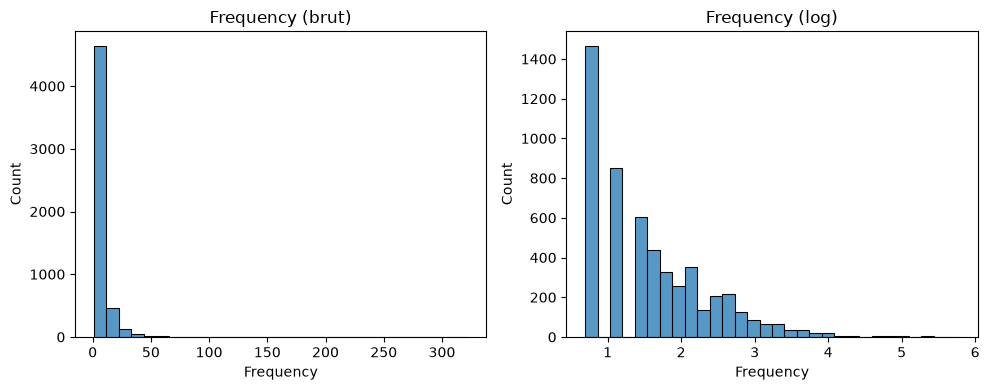

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(rfm['Frequency'], bins=30, ax=axes[0])
axes[0].set_title('Frequency (brut)')

sns.histplot(np.log1p(rfm['Frequency']), bins=30, ax=axes[1])
axes[1].set_title('Frequency (log)')

plt.tight_layout()
plt.show()

Même conclusion, la version brute est écrasée sur les 2-3 premières valeurs, la version log révèle une vraie distribution (pic autour de 1-1.5 puis une décroissance progressive) qui reste tout de même légèrement asymétrique à droite mais qui est beaucoup plus exploitable pour un algorithme basé sur la distance comme K-means.

La forte concentration de Frequency sur de faibles valeurs confirme ce qu'on observait déjà en étape 3.3, la majorité des clients sont des acheteurs occasionnels (peu de commandes), avec une minorité de clients très réguliers qui étirent la distribution. La version log rend cette hétérogénéité plus lisible pour le clustering à venir.

## 5) Segmentation - Méthode 1 : Scoring RFM par quintiles :

**Découpage en quintiles :**

In [80]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], q=5, labels=False, duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

Le sens des labels est important et différent pour Recency : un client avec une Recency faible (achat récent) est un bon client, donc on lui donne le score 5. C'est pourquoi les labels sont inversés ([5, 4, 3, 2, 1]), le quintile le plus bas de Recency (valeurs les plus faibles = achats récents) reçoit le score le plus élevé. Pour Monetary, c'est l'inverse qui est vrai : plus la valeur est élevée, meilleur est le client donc les labels suivent l'ordre suivant ([1, 2, 3, 4, 5]), le quintile le plus haut recevant le score 5.

In [81]:
rfm['F_score'].value_counts().sort_index()

F_score
0    2316
1    1042
2     937
3    1039
Name: count, dtype: int64

Le découpage en quintiles de Frequency n'a produit que 4 groupes distincts (au lieu de 5), en raison d'une forte concentration de clients sur Frequency=1 (2 316 clients sur 5 334, soit ~43%), cette valeur unique regroupe à elle seule presque un quintile et demi. Cette limite reflète l'asymétrie déjà observée en 3.3 et sera reprise en compte dans l'interprétation du score RFM combiné.

In [82]:
rfm['F_score'] = rfm['F_score'] + 1

Pour éviter d'avoir un score qui commence à 0. On rajoute un +1, l'échelle réelle sera alors de 1 à 4.

In [83]:
rfm['F_score'].value_counts().sort_index()

F_score
1    2316
2    1042
3     937
4    1039
Name: count, dtype: int64

**Score RFM combiné :**

In [84]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

**Mapping vers des labels métier :**

Nous traduisons maintenant les scores R, F, M (1 à 5 pour Recency et Monetary, 1 à 4 pour Frequency) en segments interprétables pour une équipe marketing, en combinant les trois dimensions plutôt que de les lire séparément :

In [85]:
def segment_client(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Clients fidèles'
    elif r >= 4 and f <= 2:
        return 'Nouveaux clients'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'À risque'
    elif r <= 2 and f <= 2:
        return 'Perdus'
    elif r == 3:
        return 'Clients réguliers'
    else:
        return 'Autres'

rfm['Segment'] = rfm.apply(segment_client, axis=1)

Segment | Profil | Logique :

**Champions** - R élevé, F élevé, M élevé - Clients récents, fréquents et à forte valeur

**Clients fidèles** - R élevé, F correct - Achètent régulièrement sans être forcément les plus gros dépensiers

**Nouveaux clients** - R élevé, F faible - Achat récent mais peu d'historique, encore à fidéliser

**À risque** - R faible, F faible - Anciens bons clients qui n'ont pas acheté récemment, à relancer 

**Perdus** - R faible, F faible - N'ont pas acheté récemment et n'avaient de toute façon qu'un faible historique

**Clients réguliers** - R médian - Ni assez récents ni assez anciens pour les catégories ci-dessus avec des comportements F et M dispersé

**Autres** - Combinaison de scores non couvertes représentant un volume résiduel

La catégorie "Clients réguliers" a été ajoutée après avoir constaté que R_score=3 (valeur médiane) n'était couverte par aucune règle initiale augmentant alors la taille du segment "Autres" qui est difficilement exploitable.

**Tableau récapitulatif :**

In [86]:
recap = rfm.groupby('Segment').agg(
    Nb_clients=('Customer ID', 'count'),
    CA_total=('Monetary', 'sum')
).sort_values('CA_total', ascending=False)

recap['Pct_clients'] = (recap['Nb_clients'] / recap['Nb_clients'].sum() * 100).round(1)
recap['Pct_CA'] = (recap['CA_total'] / recap['CA_total'].sum() * 100).round(1)

recap

,Nb_clients,CA_total,Pct_clients,Pct_CA
Segment,,,,
Champions,798,8584225.60,15.0,60.1
Clients réguliers,1066,1940468.02,20.0,13.6
Perdus,1867,1108638.08,35.0,7.8
Clients fidèles,485,1014425.49,9.1,7.1
Nouveaux clients,853,801682.68,16.0,5.6
À risque,61,458004.32,1.1,3.2
Autres,204,381314.56,3.8,2.7


Le tableau récapitulatif nous montre un déséquilibre CA/clients massif et net sur "Champions". En effet, 15% des clients (798) génèrent 60,1% du CA total. C'est un ratio très fort, typique du principe de Pareto. Le segment "Perdus" est le plus gros segment en nombre, mais quasi négligeable en valeur 35% des clients (1 867) ne représentent que 7,8% du CA. Cela illustre bien pourquoi le scoring RFM est utile, la taille d'un segment ne dit rien de sa valeur business, un tri uniquement par nombre de clients aurait donné une image totalement différente. Le segment "À risque" est très restreint (61 clients, 1,1%) c'est cohérent avec la logique de la fonction segment_client, ce segment demande à la fois un frequency >= 4 ET un monetary >= 4 combiné à un recency <= 2, ce qui est une condition assez restrictive (peu de clients cumulent un historique d'achat fort ET une inactivité récente).

**Limites :** 

Les seuils (R≥4, R≤2, etc.) sont un choix arbitraire mais raisonné, pas une règle universelle.

Le déséquilibre d'échelle sur F_score (1-4 au lieu de 1-5, cf. section précédente) rend les seuils sur F légèrement moins comparables à ceux de R et M.

Cette méthode traite chaque client de façon indépendante, sans tenir compte d'interactions plus subtiles entre les 3 dimensions.

## 6) Segmentation — Méthode 2 : Clustering K-Means :

### 6.1) Préparation des données :

In [87]:
from sklearn.preprocessing import StandardScaler

On va appliquer une transformation logarithmique aux variables Frequency et Monetary afin de réduire leur asymétrie et l'influence des valeurs extrêmes, avant leur standardisation.

In [88]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

### 6.2) Nombre optimal de clusters :

Après avoir standardisé les variables RFM, il est nécessaire de déterminer le nombre de clusters à retenir pour appliquer l'algorithme K-Means. Pour cela, nous testons différentes valeurs de k comprises entre 2 et 10. La méthode du coude et le score de silhouette sont utilisés comme critères d'aide à la sélection du nombre optimal de clusters. La première repose sur l'évolution de l'inertie, tandis que la seconde permet d'évaluer la qualité de la séparation des clusters.

L'inertie mesure la compacité des clusters : plus elle est faible, mieux c'est. On cherche sur le graphique un « coude », c'est-à-dire le point à partir duquel augmenter k apporte une amélioration beaucoup plus faible. L'inertie diminue toujours quand k augmente, donc on ne choisit pas simplement le k avec la plus petite inertie.

Le score de silhouette mesure à quel point les individus sont proches des individus de leur propre cluster et éloignés des autres clusters. Plus le score est élevé, mieux c'est, si le score est proche de 1 on aura une très bonne séparation, si il est proche de 0 on aura des clusters qui se chevauchent.

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

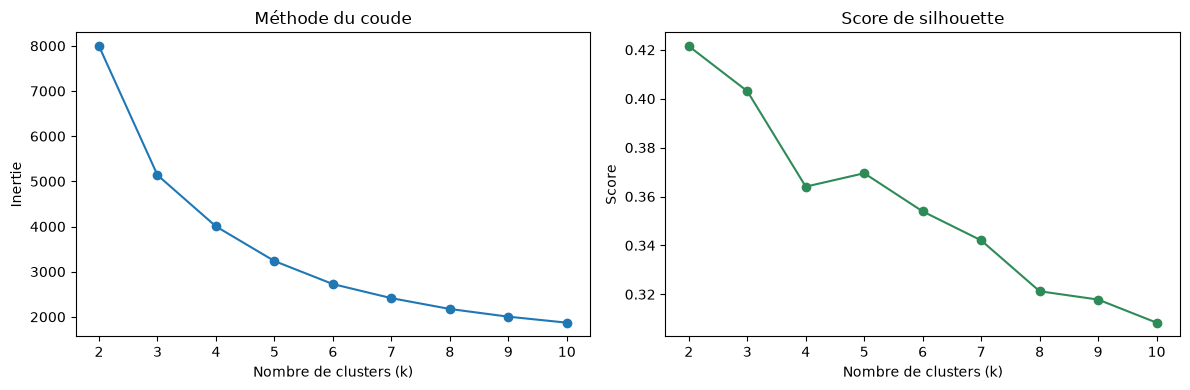

In [90]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Méthode du coude')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')

axes[1].plot(k_range, silhouettes, marker='o', color='seagreen')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

Le score de silhouette est maximal à k=2, mais ce choix ne permet pas une segmentation suffisamment fine pour un usage marketing (seulement 2 groupes). En combinant le coude de la méthode d'inertie (ralentissement net à partir de k=4) et un score de silhouette localement élevé à k=4-5, l'écart de silhouette étant minime entre k=4 et k=5 avec 0.369 pour k=5 et 0.363 pour k=4, nous retenons k=4, qui constitue un compromis entre qualité statistique du clustering et interprétabilité métier.

### 6.3) Entraînement du modèle finale : 

Le k optimal choisi pour l'entraînement du modèle finale est donc k=4.

In [91]:
k_optimal = 4  # k optimal choisie à partir des deux graphiques ci-dessus

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts().sort_index()

Cluster
0    1490
1    1341
2     801
3    1702
Name: count, dtype: int64

### 6.4) Interprétations des clusters : 

In [92]:
cluster_profile = rfm.groupby('Cluster').agg(
    Nb_clients=('Customer ID', 'count'),
    Recency_moy=('Recency', 'mean'),
    Frequency_moy=('Frequency', 'mean'),
    Monetary_moy=('Monetary', 'mean'),
    CA_total=('Monetary', 'sum')
).round(1)

cluster_profile['Pct_clients'] = (cluster_profile['Nb_clients'] / cluster_profile['Nb_clients'].sum() * 100).round(1)
cluster_profile['Pct_CA'] = (cluster_profile['CA_total'] / cluster_profile['CA_total'].sum() * 100).round(1)

cluster_profile

,Nb_clients,Recency_moy,Frequency_moy,Monetary_moy,CA_total,Pct_clients,Pct_CA
Cluster,,,,,,,
0,1490,494.0,1.7,486.5,724927.6,27.9,5.1
1,1341,105.4,1.8,433.4,581209.3,25.1,4.1
2,801,39.3,22.9,12181.4,9757295.5,15.0,68.3
3,1702,100.8,5.9,1895.0,3225326.4,31.9,22.6


**Interprétation pour chaque cluster défini :**

*Cluster 2 = Champions/VIP* :

Recency très basse (39 jours), Frequency très élevée (22,9 commandes en moyenne), Monetary énorme (12 181£ en moyenne). C'est l'équivalent des "Champions" en scoring quintiles, mais encore plus concentré : ici, 15% des clients génèrent 68,3% du CA (contre 60,1% pour Champions en section 8, dans le scoring quintiles), le clustering fait donc ressortir un groupe encore plus extrême et homogène.

*Cluster 3 = Les clients fidèles* :

Recency modérée (100,8 jours), Frequency correcte (5,9), Monetary confortable (1 895£). C'est un bon groupe intermédiaire, actif et rentable sans être extrême comme les clients Champions. Ils représentent 31,9% des clients et 22,6% du CA.

*Cluster 0 = Les clients inactifs* : 

Recency très élevée (494 jours, soit plus d'un an et demi sans achat), Frequency faible (1,7), Monetary faible (486,5£). Ce sont des clients qui sont clairement partis/perdus. Ils représentent 27,9% des clients pour seulement 5,1% du CA.

*Cluster 1 = Nouveaux clients / acheteurs occasionnels* : 

Recency élevée mais moins extrême que le cluster 0 (105,4 jours), Frequency très faible (1,8), Monetary faible (433,4£). C'est un profil proche du cluster 0 en valeur, mais avec une Recency nettement meilleure, ce serait donc plutôt des acheteurs occasionnels ou récents à un coup. Ils représentent 25,1% des clients pour seulement 4,1% du CA.

Le clustering fait ressortir une segmentation cohérente avec le scoring par quintiles, avec un léger avantage en netteté :

Cluster 2 = Champions : même logique, mais le clustering isole un groupe encore plus concentré en valeur (68,3% du CA pour le clustering contre 60,1% du CA pour la segmentations RFM en scoring quintiles).
Cluster 0 ↔ Perdus : bonne correspondance directionnelle (faible R, F, M dans les deux cas).
Clusters 1 et 3 ne correspondent pas à une découpe aussi nette que "Nouveaux clients" / "Clients fidèles" dans le scoring quintiles, le K-means semble distinguer surtout par Monetary/Frequency combinés plutôt que par Recency comme le fait la grille de règles manuelles dans la segmentation RFM en scoring quintiles.

Les deux méthodes convergent donc globalement sur les cas extrêmes (très bons clients, clients perdus), mais divergent sur les nuances intermédiaires, le clustering n'étant pas contraint par des seuils fixes prédéfinis à la main, contrairement au scoring quintiles.



In [93]:
# Exemple avec les clients UK de la liste "Quantity > 1000" de l'étape 4
rfm[rfm['Customer ID'].isin([15838.0, 17940.0])]['Cluster'].value_counts()

Cluster
2    2
Name: count, dtype: int64

In [94]:
gros_acheteurs = Df[Df['Quantity'] > 1000]['Customer ID'].unique()
rfm[rfm['Customer ID'].isin(gros_acheteurs) & (rfm['Cluster'] == 2)].shape[0]

34

Le cluster 2 regroupe les clients à forte valeur (68,3% du CA pour 15% des clients). Une vérification croisée avec les critères de quantités extrêmes définis en exploration initiale (étape 4) montre que 34 clients de ce cluster (soit ~4,2%) présentent un comportement d'achat en gros volumes, cohérent avec un profil de revendeur/petit grossiste UK. Ce sous-groupe reste minoritaire : la grande majorité du cluster 2 correspond donc à de vrais clients particuliers à forte fidélité et forte valeur, plutôt qu'à un cluster dominé par des comportements B2B. Les gros comptes internationaux identifiés initialement (ex : client 13902) ont pour leur part été exclus dès la restriction de périmètre UK.

## 7) Comparaison des deux méthodes :

### 7.1) Tableau croisé segments RFM vs clusters K-Means :

In [95]:
comparaison_pct = pd.crosstab(rfm['Segment'], rfm['Cluster'], normalize='index') * 100
comparaison_pct.round(1)

Cluster,0,1,2,3
Segment,,,,
Autres,17.6,0.0,0.5,81.9
Champions,0.0,0.0,82.1,17.9
Clients fidèles,0.0,0.4,1.4,98.1
Clients réguliers,0.0,42.8,9.9,47.3
Nouveaux clients,0.0,68.3,0.1,31.5
Perdus,77.9,16.1,0.1,5.9
À risque,0.0,0.0,47.5,52.5


### 7.2) Correspondance entre segments RFM et clusters K-Means :

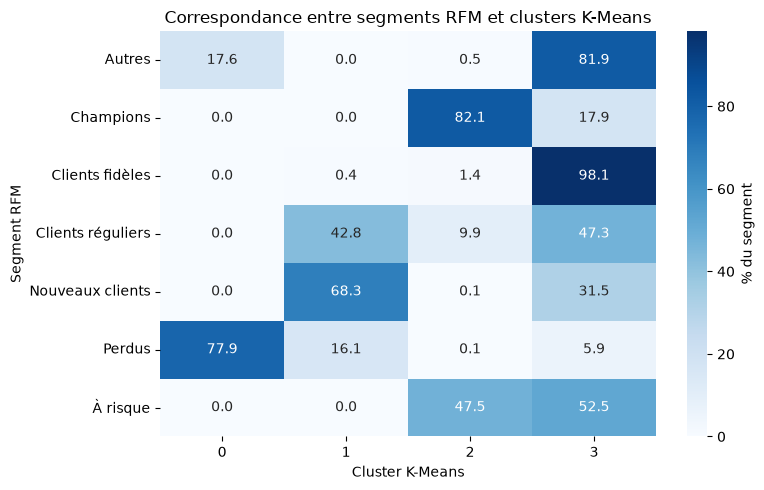

In [96]:
plt.figure(figsize=(8, 5))
sns.heatmap(comparaison_pct, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% du segment'})
plt.title('Correspondance entre segments RFM et clusters K-Means')
plt.ylabel('Segment RFM')
plt.xlabel('Cluster K-Means')
plt.tight_layout()
plt.show()

### 7.3) Interpretation :

Le croisement entre les deux méthodes de segmentation révèle une forte convergence sur les profils extrêmes : les segments 'Clients fidèles' (98,1%), 'Champions' (82,1%) et 'Perdus' (77,9%) correspondent chacun très majoritairement à un cluster K-means unique, confirmant que ces profils sont détectés de façon cohérente quelle que soit la méthode utilisée.

Les divergences apparaissent sur les segments aux règles moins tranchées : 'Clients réguliers' (issu d'un R_score médian, ajouté a posteriori en section 8) se répartit presque également entre deux clusters, de même que 'À risque', qui n'est jamais associé au cluster des clients inactifs malgré sa Recency faible, le K-means semble privilégier Frequency et Monetary dans sa séparation, alors que le scoring RFM traite Renceny, Frequency et Monetary à parts égales dans ses règles.

Ces résultats suggèrent que les deux méthodes sont complémentaires plutôt que substituables : le scoring RFM offre des règles simples et immédiatement explicables à une équipe marketing, tandis que le K-means révèle des nuances comportementales plus fines, notamment sur les segments intermédiaires où les seuils fixes du scoring peinent à capturer l'hétérogénéité réelle des clients. Les deux variables (Segment et Cluster) sont conservées dans la table finale exportée en section 11, pour permettre une analyse croisée selon les besoins.

## 8) Export final vers la base SQL :

### 8.1) Renommer les colonnes des bases de données pour SQL :

In [ ]:
# Base de donnée nettoyée 

Df_sql = Df.rename(columns={
    'Customer ID': 'customer_id',
    'Invoice': 'invoice',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'price',
    'Country': 'country',
    'TotalPrice': 'total_price'
})

In [99]:
# Base de donnée avec segmentation RFM et clustering K-means

customer_segments = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_score', 'Segment', 'Cluster']].rename(columns={
    'Customer ID': 'customer_id',
    'Recency': 'recency',
    'Frequency': 'frequency',
    'Monetary': 'monetary',
    'RFM_score': 'rfm_score',
    'Segment': 'segment_rfm',
    'Cluster': 'cluster_kmeans'
})

### 8.2) Création des tables :

#### 8.2.1) Table produits (dimension) :

In [ ]:
products = (Df_sql[['stock_code', 'description']]
            .dropna(subset=['description'])
            .groupby('stock_code')['description']
            .agg(lambda x: x.mode()[0])
            .reset_index())

#### 8.2.2) Table commandes (table de faits, sans la description) :

In [101]:
orders = Df_sql.drop(columns=['description', 'country'])

### 8.3) Export :

In [102]:
from sqlalchemy import create_engine

In [103]:
engine = create_engine('sqlite:///../data/processed/online_retail.db')

In [104]:
products.to_sql('products', engine, if_exists='replace', index=False)
orders.to_sql('orders', engine, if_exists='replace', index=False)
customer_segments.to_sql('customer_segments_python', engine, if_exists='replace', index=False)

print("Export terminé.")

Export terminé.


### 8.4) Vérifications :

#### 8.4.1) Confirmer que les 3 tables existent et contiennent des données :

In [ ]:
# Table commandes:
pd.read_sql('SELECT * FROM orders LIMIT 5', engine)

,invoice,stock_code,quantity,invoice_date,price,customer_id,total_price,Month
0,489434,85048,12,2009-12-01 07:45:00.000000,6.95,13085.0,83.4,12
1,489434,79323P,12,2009-12-01 07:45:00.000000,6.75,13085.0,81.0,12
2,489434,79323W,12,2009-12-01 07:45:00.000000,6.75,13085.0,81.0,12
3,489434,22041,48,2009-12-01 07:45:00.000000,2.10,13085.0,100.8,12
4,489434,21232,24,2009-12-01 07:45:00.000000,1.25,13085.0,30.0,12


In [ ]:
# Table produits:
pd.read_sql('SELECT * FROM products LIMIT 5', engine)

,stock_code,description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10109,BENDY COLOUR PENCILS
3,10120,DOGGY RUBBER
4,10123C,HEARTS WRAPPING TAPE


In [107]:
pd.read_sql('SELECT * FROM customer_segments_python LIMIT 5', engine)

,customer_id,recency,frequency,monetary,rfm_score,segment_rfm,cluster_kmeans
0,12346.0,326,3,77352.96,225,Perdus,2
1,12608.0,405,1,415.79,212,Perdus,0
2,12745.0,487,2,723.85,113,Perdus,0
3,12746.0,541,1,254.55,111,Perdus,0
4,12747.0,2,26,8898.48,545,Champions,2


#### 8.4.2) Vérifier les volumes :